In [1]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
def load_grayscale_image(path):
    image = Image.open(path).convert('L')
    return np.array(image)

In [3]:
def save_image(arr, path):
    arr = np.clip(arr, 0, 255)
    image = Image.fromarray(arr.astype('uint8'))
    image.save(path)

In [4]:
def zero_padding(img, pad_width, pad_height):
    padded_img = np.zeros((img.shape[0] + 2 * pad_height, img.shape[1] + 2 * pad_width))
    padded_img[pad_height:-pad_height, pad_width:-pad_width] = img
    return padded_img

In [5]:
def add_gaussian_noise(img, mean=0, std=15):
    noise = np.random.normal(mean, std, img.shape)
    noisy_img = img + noise
    return np.clip(noisy_img, 0, 255)

In [6]:
def convolution2d(img, kernel):
    kernel_height, kernel_width = kernel.shape

    flipped_kernel = np.flipud(np.fliplr(kernel))

    pad_h = kernel_height // 2
    pad_w = kernel_width // 2

    padded_img = zero_padding(img, pad_w, pad_h)

    output = np.zeros_like(img)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            region = padded_img[i:i+kernel_height, j:j+kernel_width]
            output[i, j] = np.sum(region * flipped_kernel)

    return output

In [7]:
def gaussian_kernel(size=7, sigma=1.0):
    ax = np.arange(-(size//2), size//2 + 1)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    kernel = kernel / np.sum(kernel)
    return kernel

In [10]:
kernel = np.array([
        [1,0,-1],
        [2,0,-2],
        [1,0,-1]
    ])

sharpening_kernel = np.array([
    [1,4,6,4,1],
    [4,16,24,16,4],
    [6,24,-476,24,6],
    [4,16,24,16,4],
    [1,4,6,4,1]
]) * (1.0/256.0)

In [12]:
dog = load_grayscale_image("dog.jpg")
noisy_dog = add_gaussian_noise(dog, mean=0, std=15)
save_image(noisy_dog, "noisy_dog.jpg")

edge_result = convolution2d(dog, kernel)
save_image(edge_result, "edge_result.jpg")

g_kernel = gaussian_kernel(size=7, sigma=1.0)
denoised = convolution2d(noisy_dog, g_kernel)
save_image(denoised, "denoised_dog.jpg")

sharpened = convolution2d(dog, sharpening_kernel)
save_image(sharpened, "sharpened_dog.jpg")

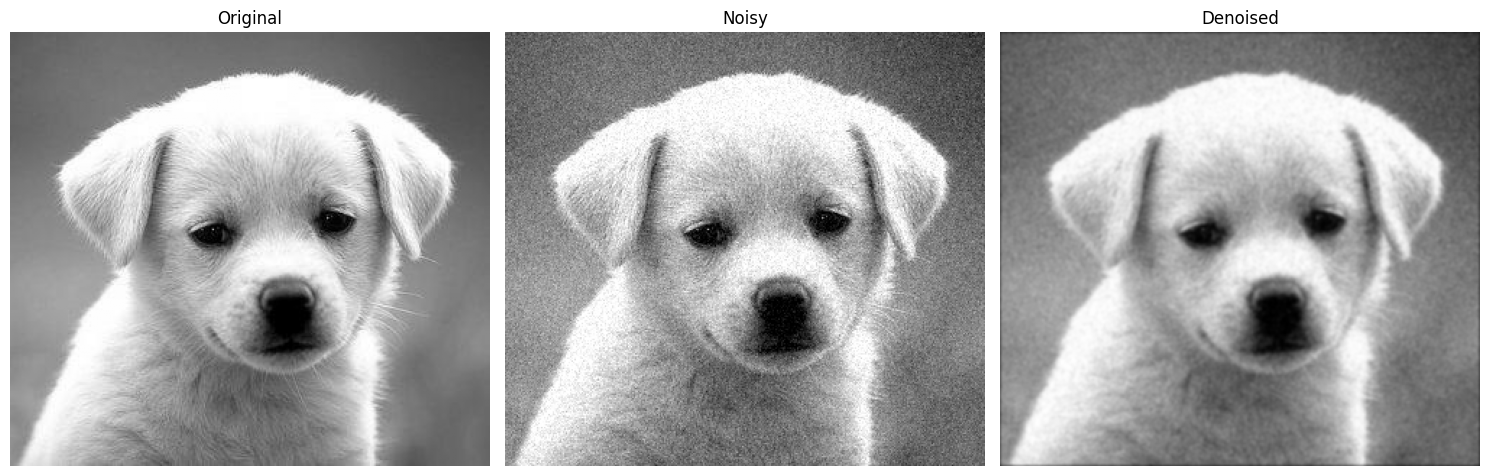

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(dog, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(noisy_dog, cmap='gray')
axes[1].set_title('Noisy')
axes[1].axis('off')

axes[2].imshow(denoised, cmap='gray')
axes[2].set_title('Denoised')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [17]:
def template_match_convolution(image, template):
    image = image - np.mean(image)
    template = template - np.mean(template)
    return convolution2d(image, template)

In [20]:
def template_match_correlation(image, template):

    image = image - np.mean(image)
    template = template - np.mean(template)

    # Ensure odd template size
    if template.shape[0] % 2 == 0:
        template = template[:-1, :]
    if template.shape[1] % 2 == 0:
        template = template[:, :-1]

    kernel_height, kernel_width = template.shape
    pad_h = kernel_height // 2
    pad_w = kernel_width // 2

    padded_image = np.pad(image,
                          ((pad_h, pad_h),
                           (pad_w, pad_w)),
                          mode='constant')

    output = np.zeros_like(image)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded_image[i:i+kernel_height,
                                  j:j+kernel_width]

            output[i, j] = np.sum(region * template)

    return output

In [24]:
def draw_bounding_box(image, top_left, template_shape, color=(255,0,0), thickness=3):
    """
    Draw rectangle on image.
    image must be RGB.
    """
    img = image.copy()
    h, w = template_shape

    y, x = top_left

    # Top border
    img[y:y+thickness, x:x+w] = color
    # Bottom border
    img[y+h-thickness:y+h, x:x+w] = color
    # Left border
    img[y:y+h, x:x+thickness] = color
    # Right border
    img[y:y+h, x+w-thickness:x+w] = color

    return img

In [25]:
shelf_gray = load_grayscale_image("shelf.jpg")
template = load_grayscale_image("template.jpg")

conv_result = template_match_convolution(shelf_gray, template)
corr_result = template_match_correlation(shelf_gray, template)

conv_y, conv_x = np.unravel_index(np.argmax(conv_result), conv_result.shape)
corr_y, corr_x = np.unravel_index(np.argmax(corr_result), corr_result.shape)

shelf_rgb = np.stack([shelf_gray]*3, axis=-1).astype(np.uint8)

conv_box_img = draw_bounding_box(shelf_rgb, (conv_y, conv_x), template.shape, color=(255,0,0))
corr_box_img = draw_bounding_box(shelf_rgb, (corr_y, corr_x), template.shape, color=(0,255,0))

save_image(conv_box_img, "conv_detection.jpg")
save_image(corr_box_img, "corr_detection.jpg")

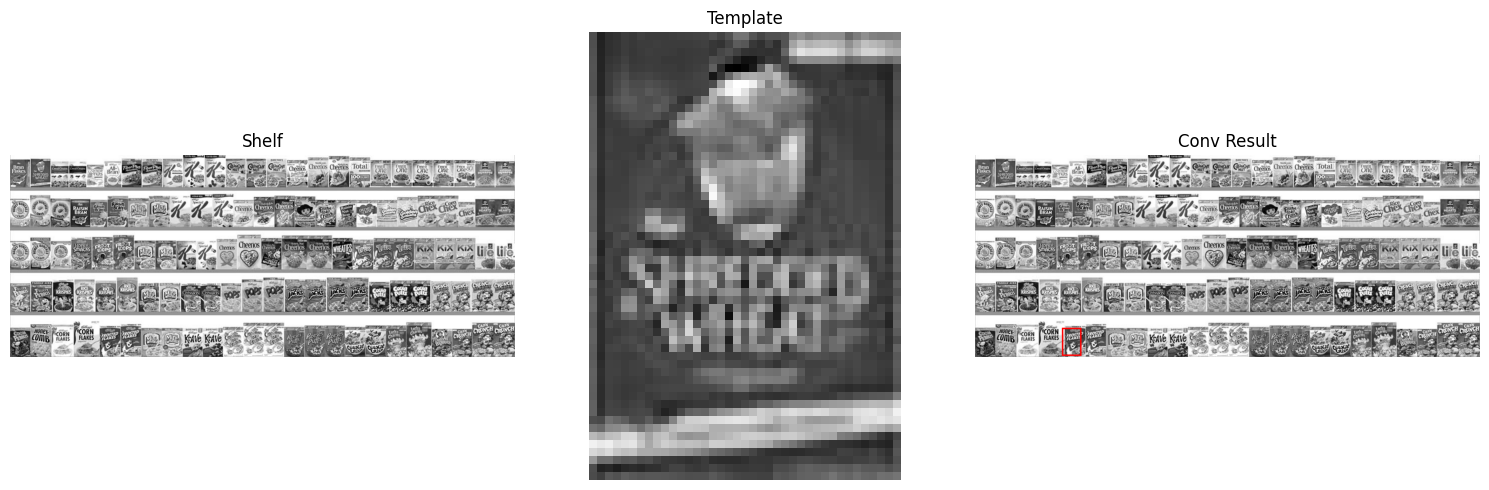

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(shelf, cmap='gray')
axes[0].set_title('Shelf')
axes[0].axis('off')

axes[1].imshow(template, cmap='gray')
axes[1].set_title('Template')
axes[1].axis('off')

axes[2].imshow(conv_box_img, cmap='gray')
axes[2].set_title('Conv Result')
axes[2].axis('off')

plt.tight_layout()
plt.show()

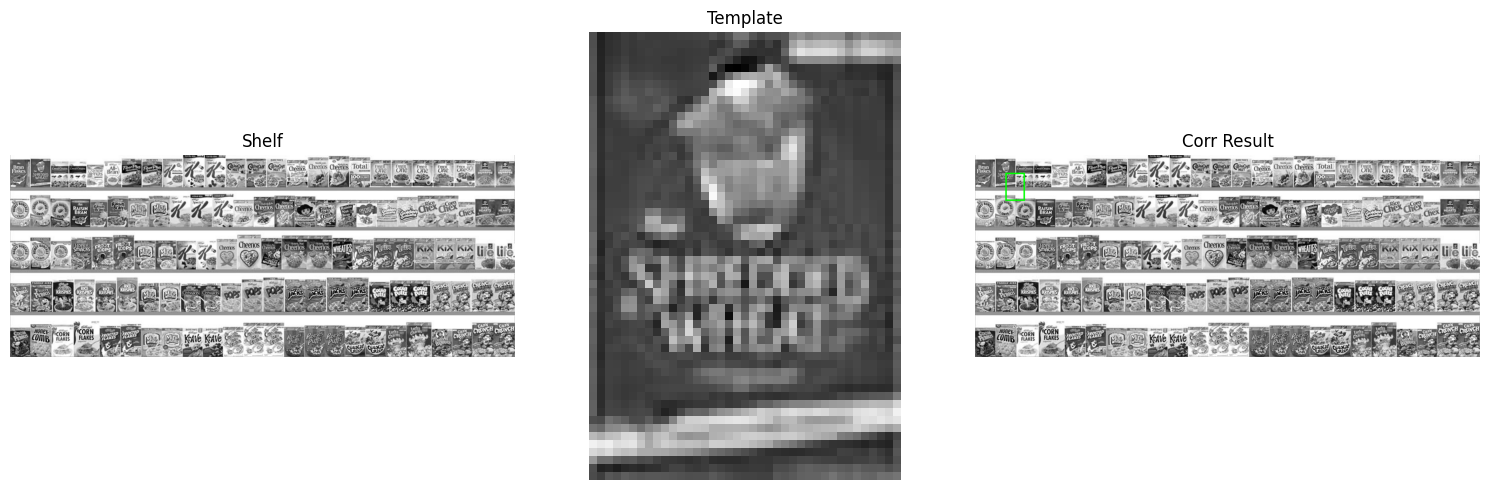

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(shelf, cmap='gray')
axes[0].set_title('Shelf')
axes[0].axis('off')

axes[1].imshow(template, cmap='gray')
axes[1].set_title('Template')
axes[1].axis('off')

axes[2].imshow(corr_box_img, cmap='gray')
axes[2].set_title('Corr Result')
axes[2].axis('off')

plt.tight_layout()
plt.show()